# <b>Car Price Prediction Project</b>

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("../data/data.csv")
#len(df)
print("Dataset shape:", df.shape)

Dataset shape: (11914, 16)


In [3]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


##### <b>Observations on Data:</b>
- There are some data inconsitencies in the way columns are labeled
- Some columns have underscores, some do not, some with capital letters and some do not.
- on <b>Transmission Type:</b>
    - df["Transmission Type"] is working
    - df.Transmission Type is not working because of space

#### <b>Cleaning:</b>
- To make the columns more consistent we might decide to make them all lowercased or we might replace spaces with underscores.

In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_', regex=False)

string_columns = list(df.dtypes[df.dtypes == 'object'].index)

for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_', regex=False)

In [5]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


### <b>Exploratory Data Analysis </b>

#### <b>Distribution of Price:</b>

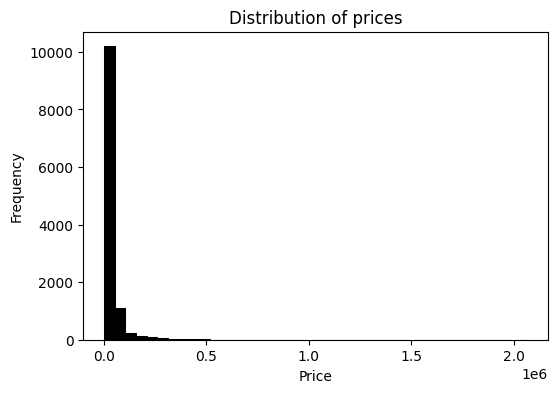

In [6]:
plt.figure(figsize=(6, 4))

sns.histplot(df.msrp, bins=40, color='black', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('Price')
plt.title('Distribution of prices')

plt.show()

##### <b> Note: </b>
- What you can see in the histogram, there are lots of prices that are pretty cheap but only a few cars that are very expensive. It means this is a long-tail distribution (many prices in a small range, but a few prices in a wide range). 
- We need to zoom in a bit to “ignore” the long tail with too less datapoints.

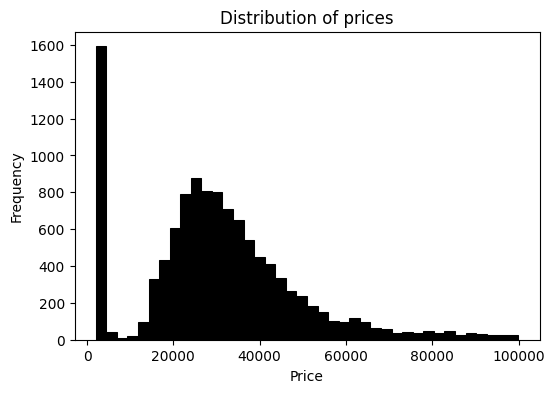

In [7]:
plt.figure(figsize=(6, 4))

sns.histplot(df.msrp[df.msrp < 100000], bins=40, color='black', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('Price')
plt.title('Distribution of prices')

plt.show()

##### <b> Note: </b>
- This kind of distribution (long tail, and the peak) is not good for ML models, because this distribution will confuse them.
- There is a way to get rid of the long tail, by applying logarithm to the price.
- This results in more compact values.

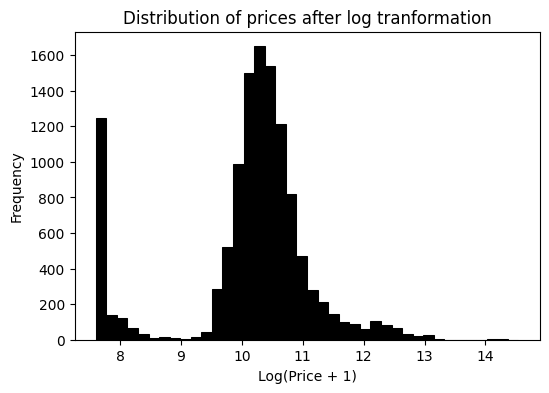

In [8]:
log_price = np.log1p(df.msrp)

plt.figure(figsize=(6, 4))

sns.histplot(log_price, bins=40, color='black', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Distribution of prices after log tranformation')

plt.show()

##### <b> Note: </b>
- You can see the long tail is gone and you see a nice bell curve shape of a so called normal distribution, what is ideal for ML models.
- But still there is the strange peak. 
- This could be the minimum price of $1,000 of the platform.

#### <b>Missing Values:</b>

- As the title suggests, this is about finding missing values (NaN values).
- The sum() sums across columns and shows for each column how much missing values are there.
- This information is important when training a model.

In [9]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

#### <b> Validation Framework </b>
<br>

- To validate the model, we take the dataset and split it into three parts (train-val-test / 60-20-20).
- This means that we train the model on the training dataset, check if it works fine on the validation dataset, and leave the test dataset for the end.
- We only use the test dataset very occasionally, and only to check if the model is performing well.
- For each of these three parts, we create the feature matrix X and the target variable y (Xtrain, ytrain, Xval, yval, Xtest, ytest).
- So, what we need to do is calculate how much 20% is.

In [10]:
np.random.seed(42)

n = len(df)

n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [11]:
y_train_orig = df_train.msrp.values
y_val_orig = df_val.msrp.values
y_test_orig = df_test.msrp.values

y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

#### <b> Linear Regression </b>

In [12]:
def train_linear_regression(X, y):
    ones = np.ones((X.shape[0],1))
    X = np.column_stack([ones, X])

    XTX = X.T @ X
    XTX_inv = np.linalg.pinv(XTX)
    w = XTX_inv @ X.T @ y
    
    return w[0], w[1:]

#### <b>Baseline Solution</b>

In [13]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [14]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [15]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

In [16]:
y_pred = w_0 + X_train.dot(w)

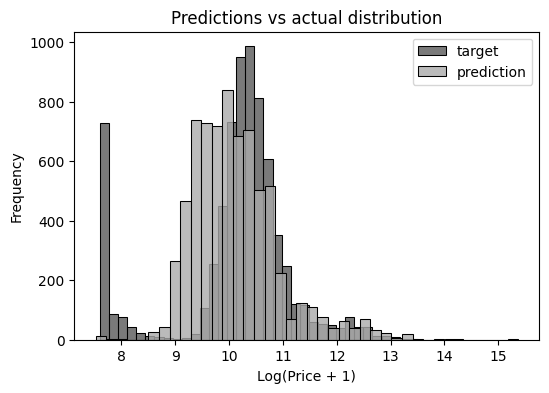

In [17]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution')

plt.show()

In [18]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [19]:
rmse(y_train, y_pred)

np.float64(0.7570200472453603)

In [20]:
X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)

In [21]:
rmse(y_val, y_pred)

np.float64(0.7398184285114164)

#### <b> Feature Engineering </b>

In [22]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [23]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation', rmse(y_val, y_pred))

train 0.5182071904488224
validation 0.5133241025837093


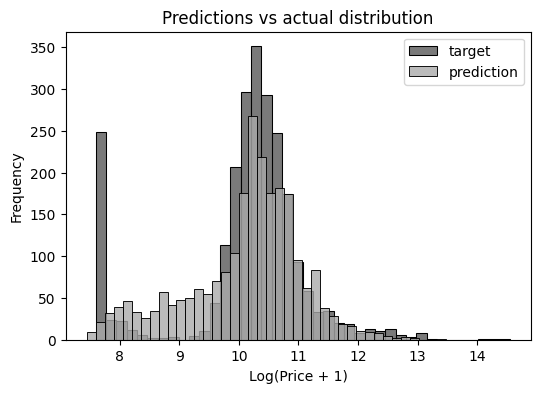

In [24]:
plt.figure(figsize=(6, 4))

sns.histplot(y_val, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution')

plt.show()

In [25]:
df['make'].value_counts().head(5)

make
Chevrolet     1123
Ford           881
Volkswagen     809
Toyota         746
Dodge          626
Name: count, dtype: int64

In [26]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        feature = 'num_doors_%s' % v
        df[feature] = (df['number_of_doors'] == v).astype(int)
        features.append(feature)

    for v in ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']:
        feature = 'is_make_%s' % v
        df[feature] = (df['make'] == v).astype(int)
        features.append(feature)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [27]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train:', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

train: 0.5163655828815651
validation: 0.5108230515514368


In [28]:
df["engine_fuel_type"].value_counts()

engine_fuel_type
regular unleaded                                7172
premium unleaded (required)                     2009
premium unleaded (recommended)                  1523
flex-fuel (unleaded/E85)                         899
diesel                                           154
electric                                          66
flex-fuel (premium unleaded required/E85)         54
flex-fuel (premium unleaded recommended/E85)      26
flex-fuel (unleaded/natural gas)                   6
natural gas                                        2
Name: count, dtype: int64

In [29]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for value in [2, 3, 4]:
        feature = 'num_doors_%s' % value
        df[feature] = (df['number_of_doors']==value).astype(int)
        features.append(feature)

    for value in ['chevrolet','ford', 'volkswagen', 'toyota', 'dodge']:
        feature = 'is_make_%s' % value
        df[feature] = (df['make']==value).astype(int)
        features.append(feature)

    for value in ['regular_unleaded', 'premium_unleaded_(required)', 'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)']:
        feature = 'is_type_%s' % value
        df[feature] = (df['engine_fuel_type']==value).astype(int)
        features.append(feature)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [30]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train:', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

train: 0.5163655828815651
validation: 0.5108230515514368


In [31]:
df['transmission_type'].value_counts()

transmission_type
AUTOMATIC           8266
MANUAL              2935
AUTOMATED_MANUAL     626
DIRECT_DRIVE          68
UNKNOWN               19
Name: count, dtype: int64

In [32]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for value in [2, 3, 4]:
        feature = 'num_doors_%s' % value
        df[feature] = (df['number_of_doors']==value).astype(int)
        features.append(feature)

    for value in ['chevrolet','ford', 'volkswagen', 'toyota', 'dodge']:
        feature = 'is_make_%s' % value
        df[feature] = (df['make']==value).astype(int)
        features.append(feature)

    for value in ['regular_unleaded', 'premium_unleaded_(required)', 'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)']:
        feature = 'is_type_%s' % value
        df[feature] = (df['engine_fuel_type']==value).astype(int)
        features.append(feature)

    for value in ['automatic', 'manual', 'automated_manual']:
        feature = 'is_transmission_%s' % value
        df[feature] = (df['transmission_type']==value).astype(int)
        features.append(feature)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [33]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train:', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

train: 0.5163655828815651
validation: 0.5108230515514368


In [34]:
df['driven_wheels'].value_counts()

driven_wheels
front wheel drive    4787
rear wheel drive     3371
all wheel drive      2353
four wheel drive     1403
Name: count, dtype: int64

In [35]:
df['market_category'].value_counts().head(5)

market_category
Crossover             1110
Flex Fuel              872
Luxury                 855
Luxury,Performance     673
Hatchback              641
Name: count, dtype: int64

In [36]:
df['vehicle_size'].value_counts().head(5)

vehicle_size
Compact    4764
Midsize    4373
Large      2777
Name: count, dtype: int64

In [37]:
df['vehicle_style'].value_counts().head(5)

vehicle_style
Sedan            3048
4dr SUV          2488
Coupe            1211
Convertible       793
4dr Hatchback     702
Name: count, dtype: int64

In [38]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')
    
    for v in [2, 3, 4]:
        feature = 'num_doors_%s' % v
        df[feature] = (df['number_of_doors'] == v).astype(int)
        features.append(feature)

    for v in ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']:
        feature = 'is_make_%s' % v
        df[feature] = (df['make'] == v).astype(int)
        features.append(feature)

    for v in ['regular_unleaded', 'premium_unleaded_(required)', 
              'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)']:
        feature = 'is_type_%s' % v
        df[feature] = (df['engine_fuel_type'] == v).astype(int)
        features.append(feature)

    for v in ['automatic', 'manual', 'automated_manual']:
        feature = 'is_transmission_%s' % v
        df[feature] = (df['transmission_type'] == v).astype(int)
        features.append(feature)

    for v in ['front_wheel_drive', 'rear_wheel_drive', 'all_wheel_drive', 'four_wheel_drive']:
        feature = 'is_driven_wheens_%s' % v
        df[feature] = (df['driven_wheels'] == v).astype(int)
        features.append(feature)

    for v in ['crossover', 'flex_fuel', 'luxury', 'luxury,performance', 'hatchback']:
        feature = 'is_mc_%s' % v
        df[feature] = (df['market_category'] == v).astype(int)
        features.append(feature)

    for v in ['compact', 'midsize', 'large']:
        feature = 'is_size_%s' % v
        df[feature] = (df['vehicle_size'] == v).astype(int)
        features.append(feature)

    for v in ['sedan', '4dr_suv', 'coupe', 'convertible', '4dr_hatchback']:
        feature = 'is_style_%s' % v
        df[feature] = (df['vehicle_style'] == v).astype(int)
        features.append(feature)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [39]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train:', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

train: 0.5163655828815651
validation: 0.5108230515465526


In [40]:
w_0

np.float64(10.796183146201518)

#### <b>Reularization</b>

In [41]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones((X.shape[0], 1))
    X = np.column_stack([ones, X])

    XTX = X.T @ X
    
    reg = r * np.eye(XTX.shape[0])
    reg[0,0]=0
    
    XTX = XTX + reg

    #XTX_inv = np.linalg.pinv(XTX)
    w = np.linalg.pinv(XTX) @ X.T @ y
    
    return w[0], w[1:]

In [42]:
for r in [0.000001, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w_0 + X_val.dot(w)
    print('%6s' %r, rmse(y_val, y_pred))

 1e-06 0.5108230508018475
0.0001 0.5108229764027056
 0.001 0.5108223015773797
  0.01 0.5108157066252901
   0.1 0.5107632673485801
     1 0.5107614620702748
     5 0.511235332375322
    10 0.5114327671050597


In [43]:
for r in [0, 0.0001, 0.001, 0.01, 0.1, 1, 10]:

    w_0, w = train_linear_regression_reg(X_train, y_train, r)

    y_train_pred = w_0 + X_train @ w
    y_val_pred = w_0 + X_val @ w

    print(
        r,
        rmse(y_train, y_train_pred),
        rmse(y_val, y_val_pred)
    )

0 0.5163655828815651 0.5108230515465526
0.0001 0.5163655828889158 0.5108229764027056
0.001 0.5163655836156759 0.5108223015773797
0.01 0.5163656552558251 0.5108157066252901
0.1 0.516371894265689 0.5107632673485801
1 0.5165941278946177 0.5107614620702748
10 0.5172864469871246 0.5114327671050597


In [44]:
X_train = prepare_X(df_train)

In [46]:
def evaluate_model(X_train, y_train, X_val, y_val, r):

    w0, w = train_linear_regression_reg(X_train, y_train, r)

    y_pred = w0 + X_val @ w

    return rmse(y_val, y_pred)

In [48]:
scores =[]
score = evaluate_model(X_train, y_train, X_val, y_val, r)

for r in [0,0.0001,0.001,0.01,0.1,1,10]:

    w0, w = train_linear_regression_reg(X_train, y_train, r)
    y_pred = w0 + X_val @ w
    score = rmse(y_val, y_pred)

    scores.append((r, score))

Text(0, 0.5, 'Validation RMSE')

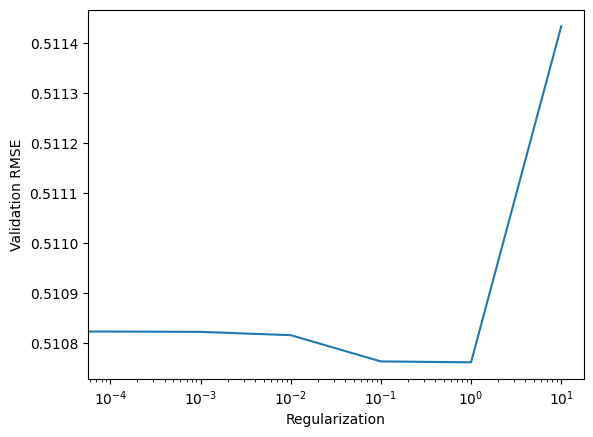

In [49]:
rs = [s[0] for s in scores]
vals = [s[1] for s in scores]

plt.plot(rs, vals)
plt.xscale('log')
plt.xlabel("Regularization")
plt.ylabel("Validation RMSE")

In [50]:
grid = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10]

for r in grid:
    
    score = evaluate_model(
        X_train,
        y_train,
        X_val,
        y_val,
        r
    )

    print("lambda =", r, "RMSE =", score)

lambda = 0 RMSE = 0.5108230515465526
lambda = 0.0001 RMSE = 0.5108229764027056
lambda = 0.001 RMSE = 0.5108223015773797
lambda = 0.01 RMSE = 0.5108157066252901
lambda = 0.1 RMSE = 0.5107632673485801
lambda = 1 RMSE = 0.5107614620702748
lambda = 10 RMSE = 0.5114327671050597


In [51]:
for r in [0, 0.001, 0.01, 0.1, 1, 10]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    print('%5s, %.2f, %.2f, %.2f' % (r, w_0, w[13], w[21]))

    0, 10.80, 0.00, 0.00
0.001, 10.79, 0.00, 0.00
 0.01, 10.78, 0.00, 0.00
  0.1, 10.68, 0.00, 0.00
    1, 10.11, 0.00, 0.00
   10, 9.43, 0.00, 0.00


In [52]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('val', rmse(y_val, y_pred))

train 0.5163655828815651
val 0.5108230515465526


In [53]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('val', rmse(y_val, y_pred))

train 0.5163656552558251
val 0.5108157066252901


In [54]:
X_train = prepare_X(df_train)
X_val = prepare_X(df_val)

for r in [0.000001, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w_0 + X_val.dot(w)
    print('%6s' %r, rmse(y_val, y_pred))

 1e-06 0.5108230508018475
0.0001 0.5108229764027056
 0.001 0.5108223015773797
  0.01 0.5108157066252901
   0.1 0.5107632673485801
     1 0.5107614620702748
     5 0.511235332375322
    10 0.5114327671050597


In [55]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

X_test = prepare_X(df_test)
y_pred = w_0 + X_test.dot(w)
print('test:', rmse(y_test, y_pred))

validation: 0.5108157066252901
test: 0.5149981597583808


#### <b>Using the Model</b>

In [56]:
i = 2
ad = df_test.iloc[i].to_dict()
ad

{'make': 'Ford',
 'model': 'F-150',
 'year': 2016,
 'engine_fuel_type': 'flex-fuel (unleaded/E85)',
 'engine_hp': 282.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'AUTOMATIC',
 'driven_wheels': 'four wheel drive',
 'number_of_doors': 4.0,
 'market_category': 'Flex Fuel',
 'vehicle_size': 'Large',
 'vehicle_style': 'Crew Cab Pickup',
 'highway_mpg': 23,
 'city_mpg': 17,
 'popularity': 5657}

In [57]:
X_test = prepare_X(pd.DataFrame([ad]))[0]
y_pred = w_0 + X_test.dot(w)
suggestion = np.expm1(y_pred)
suggestion

np.float64(38915.31158311895)